## ทด

In [1]:
import torch

ckpt = torch.load("/home/jovyan/work/MST/runs/ODELIA/DinoV2ClassifierSlice_Final/epoch=119-step=47520.ckpt", map_location="cpu")

print(type(ckpt))
print(ckpt.keys())

/tmp/ipykernel_651280/3643298785.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("/home/jovyan/work/MST/runs/ODELIA/DinoV2ClassifierSlice_Final/epoch=1

<class 'dict'>
dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'MixedPrecision', 'hparams_name', 'hyper_parameters'])


In [3]:
print(ckpt["hyper_parameters"])

{'save_hyperparameters': True, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'optimizer_kwargs': {'lr': 1e-06, 'weight_decay': 0.01}, 'lr_scheduler': None, 'lr_scheduler_kwargs': {}, 'in_ch': 3, 'out_ch': 3, 'spatial_dims': 2, 'loss': <class 'torch.nn.modules.loss.CrossEntropyLoss'>, 'loss_kwargs': {}, 'aucroc_kwargs': {'task': 'multiclass', 'num_classes': 3}, 'acc_kwargs': {'task': 'multiclass', 'num_classes': 3}, 'pretrained': True, 'save_attn': False, 'rotary_positional_encoding': None, 'model_size': 's', 'use_registers': False, 'use_bottleneck': False, 'use_slice_pos_emb': False, 'enable_linear': True, 'enable_trans': True, 'slice_fusion': 'transformer', 'freeze': False}


### Check Evaluation on map

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np

xai_method = "gradcam"

curve_dir = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/{xai_method}/attention_mask")

rows = []

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    rows.append(data)

Collection = pd.DataFrame(rows)
#print(Collection[Collection.columns[0]])
print(Collection.head(1).confidences)
print(Collection.head(1).auc)


AttributeError: 'DataFrame' object has no attribute 'confidences'

In [ ]:
print(str(Collection.iloc[1, 0]))
print(str(Collection.iloc[1, 1]))
print(str(Collection.iloc[1, 2]))



[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[[[ 5.7199526  -3.3632581  -1.5908791 ]]

 [[ 5.6409426  -3.3842282  -1.4943811 ]]

 [[ 5.586882   -3.4424956  -1.4170905 ]]

 [[ 5.595512   -3.5477839  -1.3314929 ]]

 [[ 5.5419464  -3.4575315  -1.3719033 ]]

 [[ 5.533934   -3.4026115  -1.4087132 ]]

 [[ 5.559961   -3.3169034  -1.5436081 ]]

 [[ 5.491813   -3.4466338  -1.3254489 ]]

 [[ 5.5879107  -3.2816741  -1.5924301 ]]

 [[ 5.5520306  -3.4572659  -1.38107   ]]

 [[ 5.572043   -3.3621492  -1.4783244 ]]

 [[ 5.5618196  -3.4533567  -1.3453218 ]]

 [[ 5.4289126  -3.1300652  -1.5760547 ]]

 [[ 5.224383   -2.8643126  -1.6829027 ]]

 [[ 5.0378985  -3.0708094  -1.385919  ]]

 [[ 4.905268   -3.009429   -1.4221802 ]]

 [[ 4.461562   -3.1940918  -0.9363365 ]]

 [[ 4.0256257  -3.5536952  -0.13461146]]

 [[ 3.0928268  -3.6014812   0.63730645]]

 [[ 1.7222769  -2.821164    0.9922456 ]]

 [[ 1.8818225  -2.8681397   1.4476635 ]]]
[[9.992187

See Data in Saliency

In [11]:
import numpy as np

xai_method = "gradcam"

file_path = f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/saliency_results/{xai_method}/class_2/npy/08FEB48B_right_importance.npy"

data = np.load(file_path)

print("Type:", type(data))
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print(data[1][1][0:14])
print("Data:", data)



Type: <class 'numpy.ndarray'>
Shape: (32, 224, 224)
Dtype: float32
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Data: [[[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  ...
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]]

 [[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  ...
  [0.0000000e+

In [12]:
print(data.shape)
print(data.dtype)
print(data.min(), data.max())

(32, 224, 224)
float32
0.0 0.9999987


#### Show a single slice

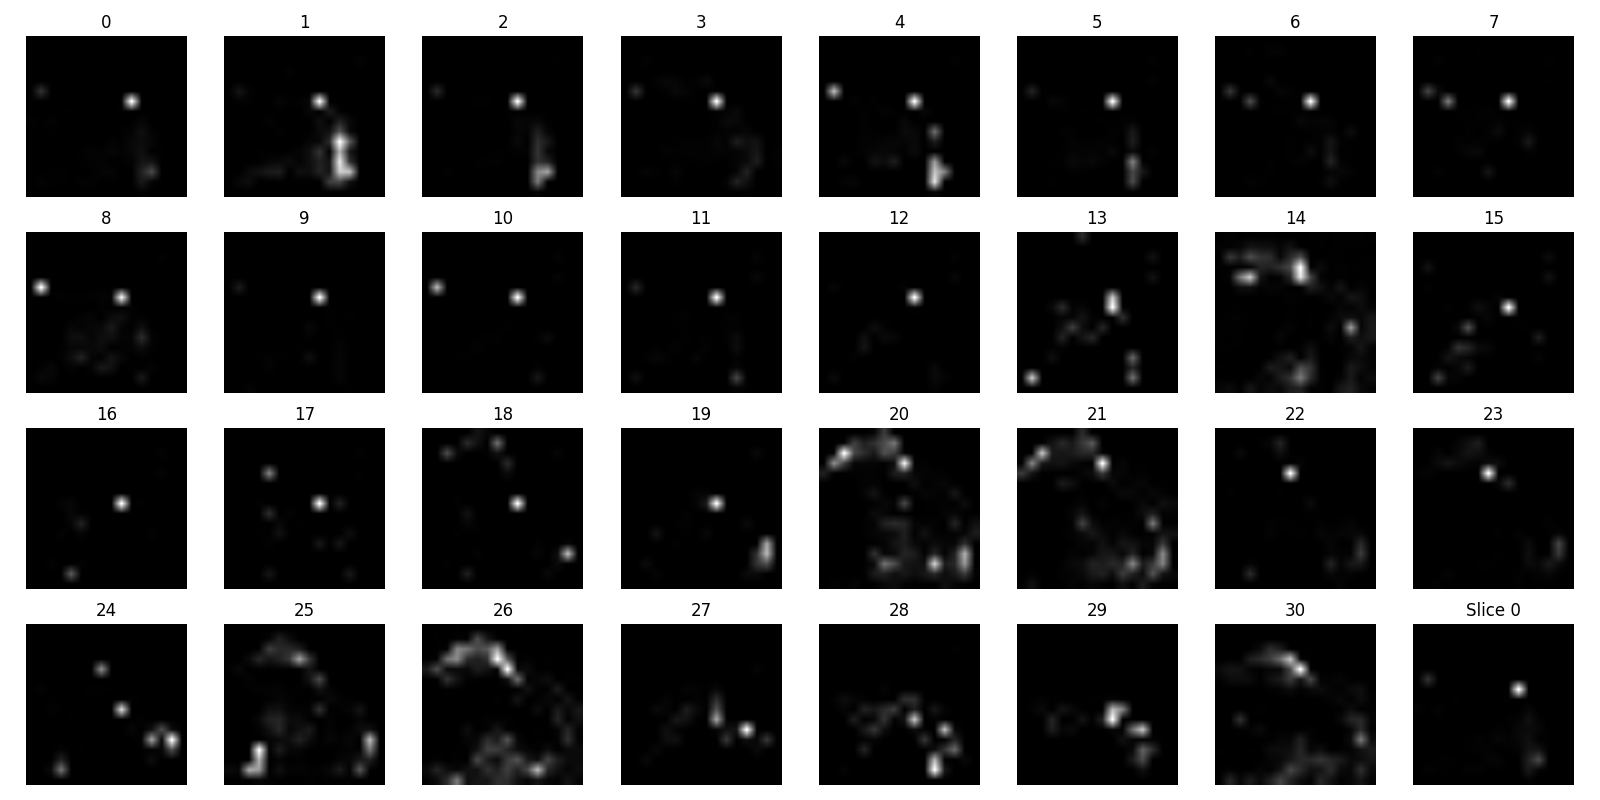

In [13]:
import matplotlib.pyplot as plt

plt.imshow(data[0], cmap="gray")
plt.title("Slice 0")
plt.axis("off")
plt.show()

Scroll through slices

In [14]:
%matplotlib widget

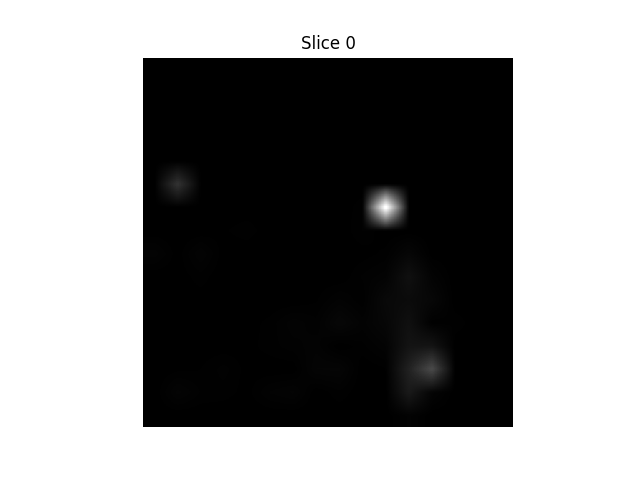

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

idx = 0
im = ax.imshow(data[idx], cmap="gray")
ax.set_title(f"Slice {idx}")
ax.axis("off")

def on_key(event):
    global idx
    if event.key == "right":
        idx = (idx + 1) % data.shape[0]
    elif event.key == "left":
        idx = (idx - 1) % data.shape[0]

    im.set_data(data[idx])
    ax.set_title(f"Slice {idx}")
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("key_press_event", on_key)
plt.show()

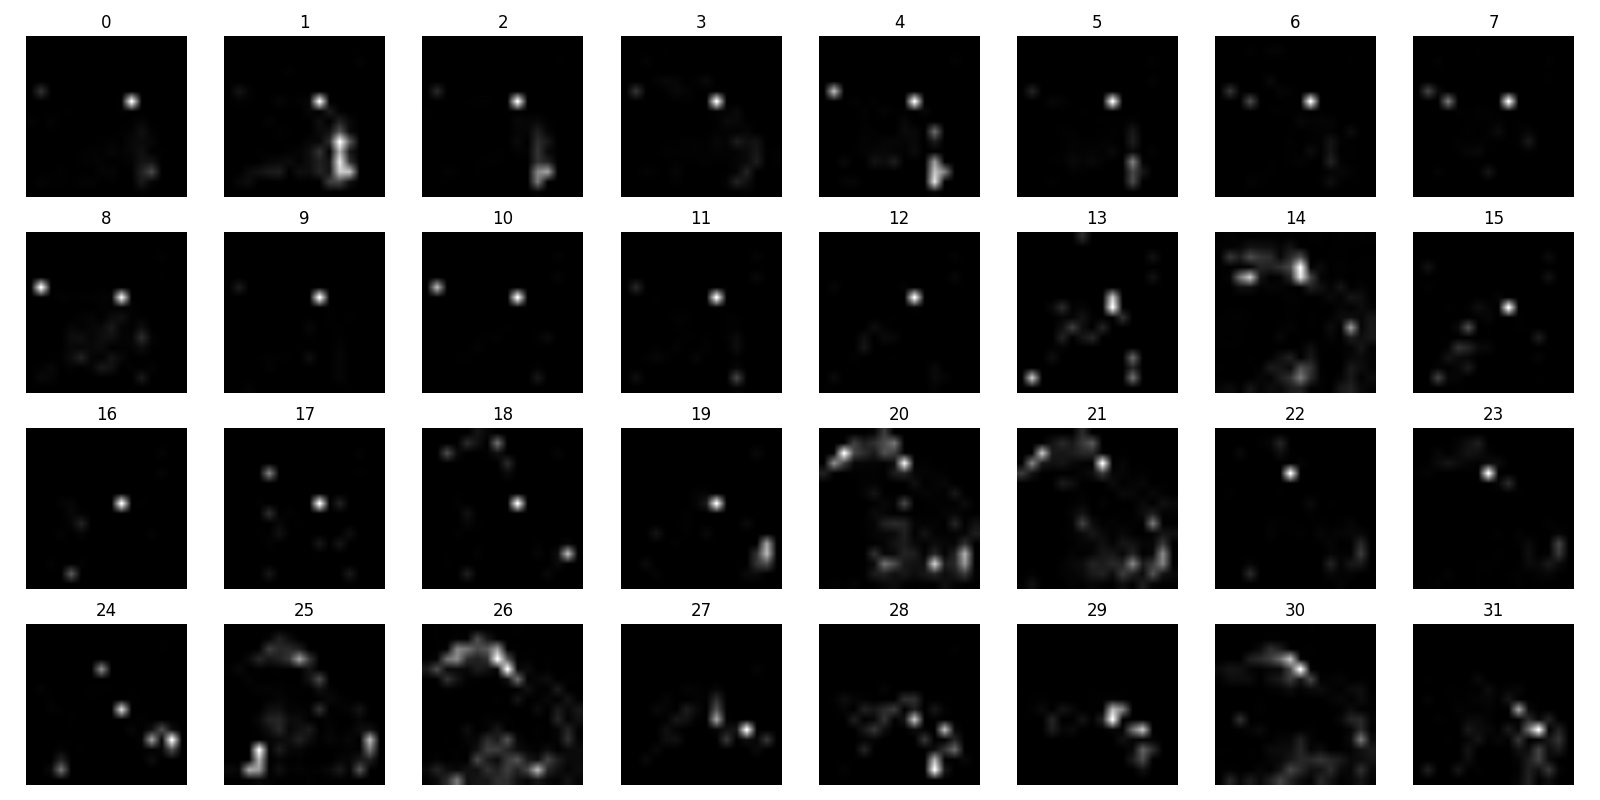

In [16]:
import matplotlib.pyplot as plt
import math

n = data.shape[0]
cols = 8
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 2*rows))

for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(data[i], cmap="gray")
        ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

Are all slices exactly the same?

In [17]:
import numpy as np

all_equal = np.all(data == data[0])
print("All slices identical:", all_equal)

All slices identical: False


Find which slices differ

In [18]:
ref = data[0]
diff_slices = [i for i in range(data.shape[0]) if not np.allclose(data[i], ref, atol=1e-6)]
print("Different slices:", diff_slices)

Different slices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
